# Laboratory work 2

## Modeling continuous radnom variable

Distribution density: $$f(x)=\frac{1}{x\ln 5},\ \ [1; 5]$$ Distribution function: $$F(x)=\begin{cases}0,\ \ x \le 1 \\ \int^x_1 f(y) dy = \frac{\ln x}{\ln 5}=\log_5 x ,\ \ 1 \le x \le 5\\ 0, \ \ x > 5 \end{cases}$$ Inverse distribution function: $$F^{-1}(x) = 5^{x}$$

> Theorem
>
> If $\alpha$ - basic random variable, $\xi$ - simulated random variable, $F(x)$ - distribution function, 
>then $\xi=F^{-1}(\alpha)$.

Importing standart libraries, setting constants and declaring distribution functions:

In [69]:
import math
from random import random

GENERATED_NUMBER = 1000

def distribution_density(x: float)->float:
    return 1 / math.log(5) / x

def distribution_function(x: float)->float:
    if x < 1: return 0
    if x > 5: return 1
    
    return 1 / math.log(5) * math.log(x)

def inverse_distribution_function(x: float)->float:
    return 5 ** x

Generating basic random variables and required random variables:

In [70]:
basic_random_variables: list[float] = [random() for _ in range(GENERATED_NUMBER)]
sample: list[float] = [inverse_distribution_function(x) for x in basic_random_variables]

## Conducting test inspection of generator:

Getting empirical mean and variance and comparing it with theoritical:
$$E\{\xi \} = \int^5_1 x f(x) dx = \int^5_1 \frac{1}{\ln 5} dx = \frac{4}{\ln 5} \approx 2.48534$$
$$V\{\xi \} = E\{\xi^2 \} - (E\{\xi \})^2 = \int^5_1 x^2 f(x) dx - \frac{16}{(\ln 5)^2} = \int^5_1 \frac{x}{\ln 5}dx - \frac{16}{(\ln 5)^2} = \frac{12}{\ln 5} - \frac{16}{(\ln 5)^2} \approx 1.27911$$

In [71]:
def mean(sample: list[float])->float:
    return sum(sample) / len(sample)

def variance(sample: list[float])->float:
    sample_mean = mean(sample)
    return sum((x - sample_mean) ** 2 for x in sample) / (len(sample)-1)

print(mean(sample))
print(variance(sample))

2.4654789231307324
1.3275898995469817


Building distribution function plot and sample histogram:

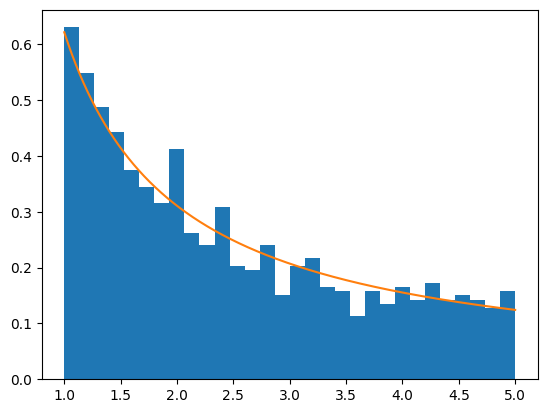

In [72]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(1, 5, 10000)
y = [distribution_density(i) for i in x]

plt.hist(sample, bins=30, density=True)
plt.plot(x, y)
plt.show()